# optimize the beeTracker into a system that utilizes the state (i.e., speed, angle, behavior, etc) to predict the next movement location in the frame.

In [1]:
import cv2 as cv 
from ultralytics import YOLO
from beemonitor.detection.motion_tracking import MotionTracking
from beemonitor.detection.nest_detector import NestDetector
from beemonitor.core.config import Config
import matplotlib.pyplot as plt
from beemonitor.ml.bee_noise_filter import BeeNoiseFilter 

In [2]:
# video path
video_to_process="/Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/short_videos/mendels_2024-05-08_15_57_03.mp4"
#video_to_process = "/Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/short_videos/mendels1_2025-04-21_17_10_05.mp4"
#video_to_process = "/Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2024-05-16_18_10_00.mp4"
#video_to_process = "/Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/short_videos/mendels1_2025-04-21_17_10_05.mp4"

In [3]:
# generic background substractor
#general_backSub = cv.createBackgroundSubtractorMOG2()

In [4]:
# initialize nest detector and get nests and hotel
config = Config.default()
nest_model = YOLO(config.models.nest_detection)
detector = NestDetector(model=nest_model, config=config)
nests = detector.get_nests_and_hotel_detections(video_path=video_to_process)

In [5]:
# initialize monitor
tracking_model = YOLO(config.models.tracking)
monitor = MotionTracking(model=tracking_model, config=config)
# read resolution-adjusted video and initialize background model
cap = cv.VideoCapture(video_to_process)
res_height = cap.get(cv.CAP_PROP_FRAME_HEIGHT)
res_width = cap.get(cv.CAP_PROP_FRAME_WIDTH)
cap.release()

In [6]:
# get substractor from monitor
x, y, x1, y1 = nests['hotel']
roi = [x, y, x1, y1]

monitor._initialize_background_from_video(video_path=video_to_process, config=config)
monitor_backSub = monitor.bg_subtractor

In [7]:
import numpy as np

# create a foreground mask based on roi
def create_roi_mask(h, w, roi):
    """
    Create a single-channel uint8 mask for the given frame dimensions and ROI.
    - frame_dim can be (height, width) or a frame.shape tuple (H, W[, C]).
    - roi is (x, y, x1, y1) with coordinates in pixel units.
    Returns a mask with 255 inside the ROI and 0 elsewhere.
    """

    x, y, x1, y1 = map(int, roi)

    # clamp roi to image bounds
    # x = max(0, min(x, w))
    # x1 = max(0, min(x1, w))
    # y = max(0, min(y, h))
    # y1 = max(0, min(y1, h))

    mask = np.zeros((h, w), dtype=np.uint8)
    if x1 > x and y1 > y:
        mask[y:y1, x:x1] = 255
    return mask

def apply_roi_to_fgmask(fg_mask, roi_mask):
    """
    Apply the ROI mask to a foreground mask (from background subtractor).
    Returns the masked foreground (same dtype as fg_mask).
    """
    return cv.bitwise_and(fg_mask, fg_mask, mask=roi_mask)

Text(0.5, 1.0, 'ROI Mask')

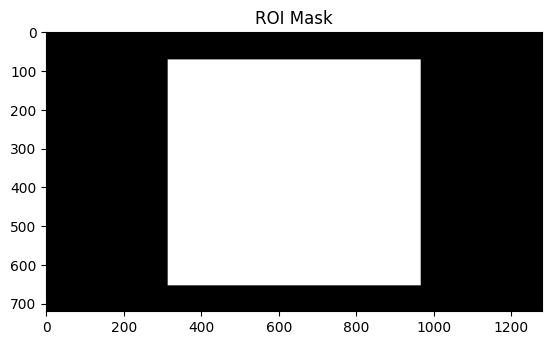

In [8]:
roi_mask = create_roi_mask(int(res_height), int(res_width), roi)
# lets visualize roi_mask in the jupyter notebook
plt.imshow(roi_mask, cmap='gray')
plt.title("ROI Mask")

In [ ]:
# define a function to clean mask using morphological operations and contour 
def get_cleaned_mask(fg_mask, kernel_size=3):
    # Define a kernel (e.g., a 3x3 or 5x5 square)
    # The size of the kernel determines how much noise is removed.
    kernel = np.ones((kernel_size, kernel_size), np.uint8) 

    # Apply Morphological Opening to remove small white noise/lines
    opened_mask = cv.morphologyEx(fg_mask, cv.MORPH_OPEN, kernel, iterations=1)

    # Optional: Apply Morphological Closing if your desired objects have small internal holes
    cleaned_mask = cv.morphologyEx(opened_mask, cv.MORPH_CLOSE, kernel, iterations=1)

    return cleaned_mask


# define another function with countoru

def get_cleaned_mask_with_contours(fg_mask, min_contour_area=50):
    # First apply morphological operations
    cleaned_mask = get_cleaned_mask(fg_mask)

    # Find contours
    contours, _ = cv.findContours(cleaned_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # Create a mask to hold filtered contours
    filtered_mask = np.zeros_like(cleaned_mask)

    for contour in contours:
        if cv.contourArea(contour) >= min_contour_area:
            cv.drawContours(filtered_mask, [contour], -1, 255, thickness=cv.FILLED)

    return filtered_mask


noise_filter = BeeNoiseFilter(
    model_path= "/Users/edwardamoah/Documents/GitHub/BeeMonitor/output/classifier_training/training_output2/best_model.pth",
    device='cpu',
    noise_threshold=0.9,
    image_size= 64
)


def get_clean_blobs_with_filter(frame, fg_mask, bee_noise_filter = noise_filter):
    # First apply morphological operations
    cleaned_mask = get_cleaned_mask_with_contours(fg_mask=fg_mask, min_contour_area=50)

    # Find contours
    contours, _ = cv.findContours(cleaned_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # Create a mask to hold filtered contours
    filtered_mask = np.zeros_like(cleaned_mask)

    blobs = []

    for contour in contours:
        x, y, w, h = cv.boundingRect(contour)
        blobs.append((x, y, w, h))  

    filtered_blobs = bee_noise_filter.filter_blobs(frame, blobs)

    #filtered_mask = []

    for blob in filtered_blobs:
        #x, y, w, h, prob = blob
        #cv.drawContours(filtered_mask, [blob], -1, 255, thickness=cv.FILLED)
        x, y, w, h, prob = blob
        cv.rectangle(filtered_mask, (x, y), (x + w, y + h), 255, thickness=cv.FILLED)

    return filtered_mask


# def get_clean_blobs_with_filter(frame, fg_mask, bee_noise_filter=noise_filter):
#     """Get cleaned blobs with noise filtering, preserving original contour shapes."""
    
#     # First apply morphological operations
#     cleaned_mask = get_cleaned_mask_with_contours(fg_mask, min_contour_area=50)

#     # Find contours
#     contours, _ = cv.findContours(cleaned_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

#     # Create mapping: blob -> original contour
#     blobs = []
#     contour_map = {}  # Map blob index to contour
    
#     for idx, contour in enumerate(contours):
#         x, y, w, h = cv.boundingRect(contour)
#         blobs.append((x, y, w, h))
#         contour_map[idx] = contour  # Store contour with its index
    
#     # Filter blobs using noise classifier
#     filtered_blobs = bee_noise_filter.filter_blobs(frame, blobs)
    
#     # Create output mask
#     filtered_mask = np.zeros_like(cleaned_mask)
    
#     # Draw only the filtered contours (not rectangles!)
#     for filtered_blob in filtered_blobs:
#         x, y, w, h, prob = filtered_blob
        
#         # Find which original contour this blob corresponds to
#         for idx, (orig_x, orig_y, orig_w, orig_h) in enumerate(blobs):
#             if x == orig_x and y == orig_y and w == orig_w and h == orig_h:
#                 # Draw the actual contour shape
#                 contour = contour_map[idx]
#                 cv.drawContours(filtered_mask, [contour], -1, 255, thickness=cv.FILLED)
#                 break
    
#     return filtered_mask

In [10]:
cap = cv.VideoCapture(video_to_process)
length = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
print("Total number of frames: ", length)

frame_idx = 0
paused = False

backSub = monitor_backSub

while True:
    # seek to the requested frame and read
    cap.set(cv.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    fgMask = backSub.apply(frame, learningRate=0)

    fgMask = apply_roi_to_fgmask(fgMask, roi_mask)

    # resize frames for display
    scale = 0.5  # shrink to 50% (adjust as needed)
    small_frame = cv.resize(frame, (0, 0), fx=scale, fy=scale, interpolation=cv.INTER_AREA)
    small_fgMask = cv.resize(fgMask, (0, 0), fx=scale, fy=scale, interpolation=cv.INTER_NEAREST)

    cv.imshow('Frame', small_frame)
    cv.imshow('FG Mask', small_fgMask)


    # Optional: Apply Morphological Closing if your desired objects have small internal holes
    cleaned_mask = get_cleaned_mask_with_contours(fgMask, 50)

    cv.imshow('FG Cleaned Mask Contours', cv.resize(cleaned_mask, (0, 0), fx=scale, fy=scale, interpolation=cv.INTER_NEAREST))

    cleaned_and_filtered_mask = get_clean_blobs_with_filter(frame, fgMask, noise_filter)


    # # resize frames for display
    scale = 0.5  # shrink to 50% (adjust as needed)
    #small_frame = cv.resize(frame, (0, 0), fx=scale, fy=scale, interpolation=cv.INTER_AREA)
    small_cleaned_mask = cv.resize(cleaned_and_filtered_mask, (0, 0), fx=scale, fy=scale, interpolation=cv.INTER_NEAREST)

    cv.imshow('FG Cleaned and Filtered Mask', small_cleaned_mask)

    # waitKey: block indefinitely when paused, else short delay for playback
    if paused:
        key = cv.waitKey(0) & 0xFF
    else:
        key = cv.waitKey(30) & 0xFF

    # Controls:
    # Space: toggle pause/resume
    # 'n' or Right Arrow: step forward one frame (also works while paused)
    # 'b' or Left Arrow: step backward one frame (also works while paused)
    # 'q' or ESC: quit
    if key in (ord('q'), 27):
        break
    elif key == ord(' '):
        paused = not paused
        if not paused:
            # advance when resuming playback
            frame_idx = min(frame_idx + 1, length - 1)
    elif key in (ord('n'), 83):  # step forward
        frame_idx = min(frame_idx + 1, length - 1)
        paused = True
    elif key in (ord('b'), 81):  # step backward
        frame_idx = max(frame_idx - 1, 0)
        paused = True
    else:
        if not paused:
            frame_idx = min(frame_idx + 1, length - 1)

cap.release()
cv.destroyAllWindows()

Total number of frames:  150
